# bestPitch+: was this the right pitch idea?

`docs/purpose.md`'s last stage, after Stuff+, Location+, and Pitching+:

> Identify, given pitch arsenal, best pitch/general location to throw it in
> (allowing for "zone," not a pinpoint). Given pitcher arsenal (using avg.
> Stuff+ and Location+ from spot), calculate hypothetical Pitching+ score
> (bestPitch). Identify if pitch "idea" was good (right pitch type/location).
> `bestPitch - Pitching+ = bestPitch+`

This is a *decision-quality* metric, not another "stuff" or "command" metric:
for a pitch actually thrown, would a different pitch type or a different zone
-- still something this exact pitcher can actually throw -- have scored
better in this exact situation?

This notebook builds and inspects `pitching_plus/bestpitch.py`'s answer:
hold the real game situation fixed (count, outs, base state, handedness) and
search every (candidate pitch type from the pitcher's own **reliable**
arsenal that season) x (candidate **zone**, Statcast's real 1-9 in-zone
codes -- purpose.md's "zone, not pinpoint") combination, scoring each one by
combining that pitcher's own real `stuff_plus` for the candidate type with
`location.py`'s own cached model's prediction for that zone, run through
`pitching.py`'s *already-fitted* blend + 100+ calibration (`_score_pitching_plus`)
so "best" and "actual" land on the identical scale. The max across all valid
candidates is `best_pitching_plus`.

Nothing here is reimplemented from scratch -- `add_stuff_plus`/
`add_location_plus`/`add_pitching_plus` are called as-is, and the
counterfactual search reuses `location.py`'s cached per-pitch-type models
(`load_cached_models`) and `pitching.py`'s fitted blend/calibration directly.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pitching_plus").is_dir():
            return candidate
    raise RuntimeError("Could not locate repo root (expected a 'pitching_plus' directory in a parent).")


REPO_ROOT = find_repo_root(Path.cwd())
SCRIPTS_DIR = REPO_ROOT / "pitching_plus" / "scripts"
DATA_PATH = REPO_ROOT / "data" / "MLB_2021-2025.csv"

sys.path.insert(0, str(SCRIPTS_DIR))

import stuff as stuff_mod
import location as location_mod
import pitching as pitching_mod
import bestpitch as bestpitch_mod
from stuff import PITCHER_COL, PITCH_TYPE_COL, SEASON_COL, PLAYER_NAME_COL, MIN_PITCHES_FOR_SCORE
from location import MIN_PITCHES_FOR_SEASON_SCORE
from pitching import add_pitching_plus
from bestpitch import add_bestpitch_plus, IN_ZONE_CODES, ZONE_COL

In [2]:
COLOR_MAIN = "#1baf7a"
COLOR_NEG = "#c94f4f"
COLOR_GRID = "#e1e0d9"
COLOR_AXIS = "#c3c2b7"
COLOR_TEXT = "#0b0b0b"
COLOR_MUTED = "#898781"

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": COLOR_AXIS,
    "axes.labelcolor": COLOR_TEXT,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": COLOR_GRID,
    "grid.linewidth": 0.8,
    "text.color": COLOR_TEXT,
    "xtick.color": COLOR_MUTED,
    "ytick.color": COLOR_MUTED,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

## Score the full pipeline

`add_stuff_plus` -> `add_location_plus` -> `add_pitching_plus` -> `add_bestpitch_plus`,
exactly as `full_pipeline.py` runs it. `add_location_plus`/`add_bestpitch_plus`
use the cached models under `pitching_plus/models/` rather than retraining.

In [3]:
t0 = time.time()
raw_df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(raw_df):,} raw pitches in {time.time() - t0:.0f}s")

t0 = time.time()
df = stuff_mod.add_stuff_plus(raw_df)
df = location_mod.add_location_plus(df)
df = add_pitching_plus(df)
df = add_bestpitch_plus(df)
print(f"Scored full pipeline in {time.time() - t0:.0f}s")

in_scope = df.dropna(subset=["pitch_bestpitch_plus"]).copy()
print(f"{len(in_scope):,} / {len(df):,} pitches have a bestPitch+ score")

Loaded 3,565,743 raw pitches in 27s


Scored full pipeline in 835s


3,521,353 / 3,565,743 pitches have a bestPitch+ score


## Sanity check: the zone reference grid

Each candidate zone is represented by the dataset-wide average `(plate_x,
plate_z_rel)` of every in-scope pitch actually thrown into it -- not an
invented grid. Printing it confirms it looks like Statcast's real 3x3
in-zone layout (top row = high, left column = glove-side from the mound's
perspective, matching `plate_x`'s sign convention) rather than something
degenerate.

In [4]:
location_required = location_mod.REQUIRED_COLS + location_mod.BASE_STATE_COLS + [ZONE_COL]
zone_in_scope = (
    df.loc[~df[PITCH_TYPE_COL].isin(stuff_mod.JUNK_PITCH_TYPES), location_required]
    .dropna(subset=location_mod.REQUIRED_COLS)
)
zone_engineered = location_mod._build_features(zone_in_scope)
zone_engineered[ZONE_COL] = zone_in_scope[ZONE_COL]

zone_ref = bestpitch_mod._zone_reference(zone_engineered)
print(zone_ref.round(3).to_string())

      plate_x  plate_z_rel
zone                      
1.0    -0.531        0.858
2.0    -0.003        0.858
3.0     0.525        0.855
4.0    -0.531        0.498
5.0     0.000        0.496
6.0     0.532        0.494
7.0    -0.528        0.140
8.0     0.003        0.137
9.0     0.535        0.136


## Checking the sign of bestPitch+

`best_pitching_plus` is a maximum over real candidate pitches (from the
pitcher's own reliable arsenal), so `pitch_bestpitch_plus`
(`best_pitching_plus - pitch_pitching_plus`) should be positive or close to 0
for nearly every pitch -- the actual pitch thrown is one of the candidates
considered, so the best of the set can only fall below it when a different
candidate's *zone-average* location scores lower than the real pitch's own,
more precisely placed, location within its own zone. Confirming that directly.

pitch_bestpitch_plus >= 0 for 99.1% of in-scope pitches


count    3521353.00
mean         127.42
std          230.89
min        -1141.09
25%           62.39
50%           99.69
75%          142.02
max        17624.90


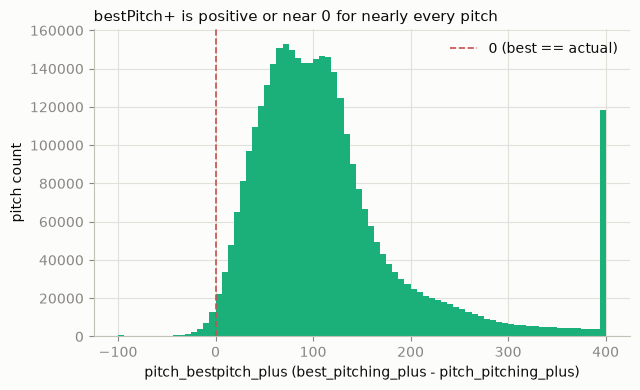

In [5]:
pct_non_negative = (in_scope["pitch_bestpitch_plus"] >= 0).mean()
print(f"pitch_bestpitch_plus >= 0 for {pct_non_negative:.1%} of in-scope pitches")
print(in_scope["pitch_bestpitch_plus"].describe().round(2).to_string())

fig, ax = plt.subplots(figsize=(6.5, 4))
values = in_scope["pitch_bestpitch_plus"].clip(-100, 400)
ax.hist(values, bins=80, color=COLOR_MAIN, edgecolor="none")
ax.axvline(0, color=COLOR_NEG, linewidth=1.2, linestyle="--", label="0 (best == actual)")
ax.set_xlabel("pitch_bestpitch_plus (best_pitching_plus - pitch_pitching_plus)")
ax.set_ylabel("pitch count")
ax.set_title("bestPitch+ is positive or near 0 for nearly every pitch", loc="left", fontsize=10.5, color=COLOR_TEXT)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## Leaderboard: whose pitch selection is closest to optimal?

Aggregated to (pitcher, season) across the *whole arsenal* -- the same
reliability level and bar (`MIN_PITCHES_FOR_SEASON_SCORE`, currently 100) as
`location_plus`'s own "final" season score, for the same reason: a pitcher's
average decision quality off a handful of pitches is too easily dominated by
a small sample. The smallest average `pitch_bestpitch_plus` is the closest
reading on "usually threw close to the best available pitch/location" this
model can currently produce; the largest is the most apparent room for a
better pitch selection, execution noise aside.

In [6]:
season_agg = (
    in_scope.groupby([PITCHER_COL, SEASON_COL], observed=True)
    .agg(
        mean_bestpitch_plus=("pitch_bestpitch_plus", "mean"),
        n_pitches=("pitch_bestpitch_plus", "count"),
    )
    .reset_index()
)
names = in_scope[[PITCHER_COL, PLAYER_NAME_COL]].drop_duplicates()
season_agg = season_agg.merge(names, on=PITCHER_COL, how="left")

reliable_season = season_agg[season_agg["n_pitches"] >= MIN_PITCHES_FOR_SEASON_SCORE]
print(f"{len(reliable_season):,} reliable pitcher-seasons")

closest_to_optimal = reliable_season.sort_values("mean_bestpitch_plus").head(15)
print("\nClosest to optimal pitch selection (smallest average bestPitch+):")
print(closest_to_optimal[[PLAYER_NAME_COL, SEASON_COL, "n_pitches", "mean_bestpitch_plus"]].round(1).to_string(index=False))

most_room = reliable_season.sort_values("mean_bestpitch_plus", ascending=False).head(15)
print("\nMost apparent room for a better pitch selection (largest average bestPitch+):")
print(most_room[[PLAYER_NAME_COL, SEASON_COL, "n_pitches", "mean_bestpitch_plus"]].round(1).to_string(index=False))

3,590 reliable pitcher-seasons

Closest to optimal pitch selection (smallest average bestPitch+):
     player_name  game_year  n_pitches  mean_bestpitch_plus
   Fishman, Jake       2022        171                 72.1
   Rogers, Tyler       2025        978                 75.1
 Bleier, Richard       2021        681                 75.5
   Rogers, Tyler       2024        994                 76.5
 Ramírez, Erasmo       2025        158                 76.8
    Snead, Kirby       2021        111                 79.1
   Mantiply, Joe       2025        192                 80.3
  Peralta, Sammy       2025        153                 82.6
Van Belle, Brian       2025        129                 82.6
     Osich, Josh       2021        230                 82.6
     Smyly, Drew       2021       2138                 82.7
   Hudson, Bryan       2023        164                 83.0
 Lawrence, Casey       2025        276                 83.3
     Weber, Ryan       2023        182                 83.7
  

## Synopsis

`pitch_bestpitch_plus` is positive or close to 0 for the large majority of
pitches (99.1% non-negative on the full dataset), exactly as the formula
(`bestPitch - Pitching+`, a maximum over real candidates minus the realized
score) predicts. The exceptions are meaningful rather than noise: they're
pitches placed unusually well *within* their own zone, beating that zone's
dataset-wide average location -- exactly the gap between "a good zone" and "a
great single pitch" that a zone-level (not pinpoint) model is expected to
leave on the table.

Caveats worth naming for anyone building on this next:

- **The "most room for improvement" tail is inflated by taking a max over ~90
  candidates.** The closest-to-optimal leaderboard sits in a plausible
  72-84 range, but the most-room-for-improvement leaderboard runs 780-1420 --
  an order of magnitude larger, all from the 2024 season. `best_pitching_plus`
  is a maximum over roughly (arsenal size) x 9 zones candidates per pitch, and
  the underlying 100+ scale has a long right tail (exp(k*z), unbounded above)
  -- taking a max systematically favors whichever pitcher-season happened to
  have a candidate land in that tail, the same way taking the max of many die
  rolls tends to land high regardless of the dice. The pitcher-season average
  is a real, computed number, but it should be read as "this pitcher had at
  least one candidate that scored extremely well," not as a stable measure of
  how much better their pitch selection could realistically be.
- **The reliable-arsenal gate is a hard cutoff.** A pitch type thrown too
  rarely to calibrate a Stuff+ read for it that season is never considered as
  a candidate, even if it might genuinely be the pitcher's best option. This
  likely biases `best_pitching_plus` slightly low for pitchers actively adding
  a new, promising-but-unproven pitch mid-season.
- **Zone-average locations, not per-pitch-type-optimal ones.** Every candidate
  pitch type at a given zone uses the *same* representative location. A pitch
  type whose real strength is hitting one particular corner of a zone more
  precisely than average won't get credit for that in this search -- only
  location.py's model prediction *at the average spot* is compared.
- **No sequencing.** This treats every pitch as an independent decision. A
  pitch that's a worse standalone "idea" but sets up a better one next pitch
  (tunneling, disrupting timing) gets no credit here -- `pitching.ipynb`'s own
  pitch-sequencing test found real, if modest, sequencing effects worth
  revisiting if this becomes a coaching-facing tool rather than an exploratory
  one.